In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("prasoonkottarathil/polycystic-ovary-syndrome-pcos")

print("Path to dataset files:", path)

100%|██████████| 120k/120k [00:00<00:00, 55.4MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/prasoonkottarathil/polycystic-ovary-syndrome-pcos/versions/3


In [2]:
import os
os.listdir(path)

['PCOS_data_without_infertility.xlsx', 'PCOS_infertility.csv']

In [3]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_excel(os.path.join(path,"PCOS_data_without_infertility.xlsx"), sheet_name="Full_new")

In [4]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [5]:
df.head()

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),Hb(g/dl),Cycle(R/I),Cycle length(days),Marraige Status (Yrs),Pregnant(Y/N),No. of aborptions,I beta-HCG(mIU/mL),II beta-HCG(mIU/mL),FSH(mIU/mL),LH(mIU/mL),FSH/LH,Hip(inch),Waist(inch),Waist:Hip Ratio,TSH (mIU/L),AMH(ng/mL),PRL(ng/mL),Vit D3 (ng/mL),PRG(ng/mL),RBS(mg/dl),Weight gain(Y/N),hair growth(Y/N),Skin darkening (Y/N),Hair loss(Y/N),Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.6,152.0,19.300000,15,78,22,10.48,2,5,7.0,0,0,1.99,1.99,7.95,3.68,2.160326,36,30,0.833333,0.68,2.07,45.16,17.1,0.57,92.0,0,0,0,0,0,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,24.921163,15,74,20,11.70,2,5,11.0,1,0,60.80,1.99,6.73,1.09,6.174312,38,32,0.842105,3.16,1.53,20.09,61.3,0.97,92.0,0,0,0,0,0,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,25.270891,11,72,18,11.80,2,5,10.0,1,0,494.08,494.08,5.54,0.88,6.295455,40,36,0.900000,2.54,6.63,10.52,49.7,0.36,84.0,0,0,0,1,1,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN
3,4,4,0,37,65.0,148.0,29.674945,13,72,20,12.00,2,5,4.0,0,0,1.99,1.99,8.06,2.36,3.415254,42,36,0.857143,16.41,1.22,36.90,33.4,0.36,76.0,0,0,0,0,0,0.0,0,120,70,2,2,15.0,14.0,7.5,NaN
4,5,5,0,25,52.0,161.0,20.060954,11,72,18,10.00,2,5,1.0,1,0,801.45,801.45,3.98,0.90,4.422222,37,30,0.810811,3.57,2.26,30.09,43.8,0.38,84.0,0,0,0,1,0,0.0,0,120,80,3,4,16.0,14.0,7.0,NaN


In [6]:
df.columns

Index(['Sl. No', 'Patient File No.', 'PCOS (Y/N)', ' Age (yrs)', 'Weight (Kg)',
       'Height(Cm) ', 'BMI', 'Blood Group', 'Pulse rate(bpm) ',
       'RR (breaths/min)', 'Hb(g/dl)', 'Cycle(R/I)', 'Cycle length(days)',
       'Marraige Status (Yrs)', 'Pregnant(Y/N)', 'No. of aborptions',
       '  I   beta-HCG(mIU/mL)', 'II    beta-HCG(mIU/mL)', 'FSH(mIU/mL)',
       'LH(mIU/mL)', 'FSH/LH', 'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio',
       'TSH (mIU/L)', 'AMH(ng/mL)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)',
       'PRG(ng/mL)', 'RBS(mg/dl)', 'Weight gain(Y/N)', 'hair growth(Y/N)',
       'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)',
       'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'BP _Systolic (mmHg)',
       'BP _Diastolic (mmHg)', 'Follicle No. (L)', 'Follicle No. (R)',
       'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)', 'Endometrium (mm)',
       'Unnamed: 44'],
      dtype='object')

In [7]:
df.columns=df.columns.str.lower().str.strip()

In [8]:
df.columns

Index(['sl. no', 'patient file no.', 'pcos (y/n)', 'age (yrs)', 'weight (kg)',
       'height(cm)', 'bmi', 'blood group', 'pulse rate(bpm)',
       'rr (breaths/min)', 'hb(g/dl)', 'cycle(r/i)', 'cycle length(days)',
       'marraige status (yrs)', 'pregnant(y/n)', 'no. of aborptions',
       'i   beta-hcg(miu/ml)', 'ii    beta-hcg(miu/ml)', 'fsh(miu/ml)',
       'lh(miu/ml)', 'fsh/lh', 'hip(inch)', 'waist(inch)', 'waist:hip ratio',
       'tsh (miu/l)', 'amh(ng/ml)', 'prl(ng/ml)', 'vit d3 (ng/ml)',
       'prg(ng/ml)', 'rbs(mg/dl)', 'weight gain(y/n)', 'hair growth(y/n)',
       'skin darkening (y/n)', 'hair loss(y/n)', 'pimples(y/n)',
       'fast food (y/n)', 'reg.exercise(y/n)', 'bp _systolic (mmhg)',
       'bp _diastolic (mmhg)', 'follicle no. (l)', 'follicle no. (r)',
       'avg. f size (l) (mm)', 'avg. f size (r) (mm)', 'endometrium (mm)',
       'unnamed: 44'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 45 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   sl. no                  541 non-null    int64  
 1   patient file no.        541 non-null    int64  
 2   pcos (y/n)              541 non-null    int64  
 3   age (yrs)               541 non-null    int64  
 4   weight (kg)             541 non-null    float64
 5   height(cm)              541 non-null    float64
 6   bmi                     541 non-null    float64
 7   blood group             541 non-null    int64  
 8   pulse rate(bpm)         541 non-null    int64  
 9   rr (breaths/min)        541 non-null    int64  
 10  hb(g/dl)                541 non-null    float64
 11  cycle(r/i)              541 non-null    int64  
 12  cycle length(days)      541 non-null    int64  
 13  marraige status (yrs)   540 non-null    float64
 14  pregnant(y/n)           541 non-null    in

In [10]:
df[df['unnamed: 44'].notna()]

,sl. no,patient file no.,pcos (y/n),age (yrs),weight (kg),height(cm),bmi,blood group,pulse rate(bpm),rr (breaths/min),hb(g/dl),cycle(r/i),cycle length(days),marraige status (yrs),pregnant(y/n),no. of aborptions,i beta-hcg(miu/ml),ii beta-hcg(miu/ml),fsh(miu/ml),lh(miu/ml),fsh/lh,hip(inch),waist(inch),waist:hip ratio,tsh (miu/l),amh(ng/ml),prl(ng/ml),vit d3 (ng/ml),prg(ng/ml),rbs(mg/dl),weight gain(y/n),hair growth(y/n),skin darkening (y/n),hair loss(y/n),pimples(y/n),fast food (y/n),reg.exercise(y/n),bp _systolic (mmhg),bp _diastolic (mmhg),follicle no. (l),follicle no. (r),avg. f size (l) (mm),avg. f size (r) (mm),endometrium (mm),unnamed: 44
180,181,181,1,30,70.0,150.0,31.111111,16,74,18,11.7,4,4,8.0,0,0,1.99,1.99,1.98,0.032,61.875,38,32,0.842105,1.98,32,14.13,74.5,0.047,100.0,1,1,0,1,0,1.0,0,120,80,8,6,12.0,11.0,4.5,.
363,364,364,0,31,48.0,152.0,20.800000,17,72,18,11.0,2,6,8.0,0,0,1.99,1.99,5.98,1.000,5.980,35,30,0.857143,3.13,1,20.83,43.4,0.560,100.0,0,0,0,1,1,1.0,0,110,80,1,3,13.0,13.0,7.0,7


In [11]:
df.drop(['unnamed: 44','sl. no','patient file no.'],axis=1,inplace=True)

In [12]:
df.isnull().sum()

,0
pcos (y/n),0
age (yrs),0
weight (kg),0
height(cm),0
bmi,0
blood group,0
pulse rate(bpm),0
rr (breaths/min),0
hb(g/dl),0
cycle(r/i),0


In [13]:
df[df['marraige status (yrs)'].isna()]

,pcos (y/n),age (yrs),weight (kg),height(cm),bmi,blood group,pulse rate(bpm),rr (breaths/min),hb(g/dl),cycle(r/i),cycle length(days),marraige status (yrs),pregnant(y/n),no. of aborptions,i beta-hcg(miu/ml),ii beta-hcg(miu/ml),fsh(miu/ml),lh(miu/ml),fsh/lh,hip(inch),waist(inch),waist:hip ratio,tsh (miu/l),amh(ng/ml),prl(ng/ml),vit d3 (ng/ml),prg(ng/ml),rbs(mg/dl),weight gain(y/n),hair growth(y/n),skin darkening (y/n),hair loss(y/n),pimples(y/n),fast food (y/n),reg.exercise(y/n),bp _systolic (mmhg),bp _diastolic (mmhg),follicle no. (l),follicle no. (r),avg. f size (l) (mm),avg. f size (r) (mm),endometrium (mm)
458,1,36,66.0,162.0,25.1,15,72,20,11.0,4,7,NaN,0,0,515.33,1.99,1.64,0.17,9.647059,39,37,0.948718,1.86,6.6,25.0,20.8,0.25,93.0,0,0,0,0,0,0.0,0,120,80,14,5,19.0,19.0,8.0


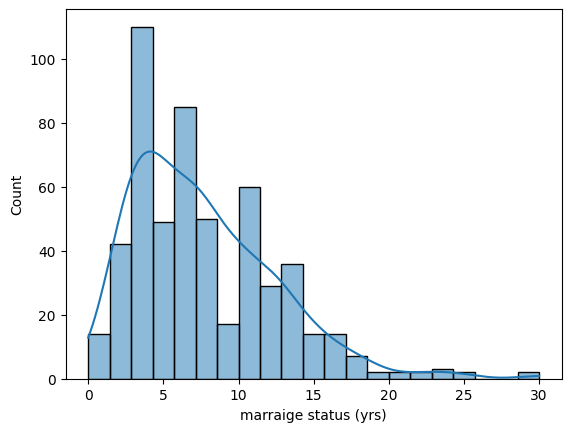

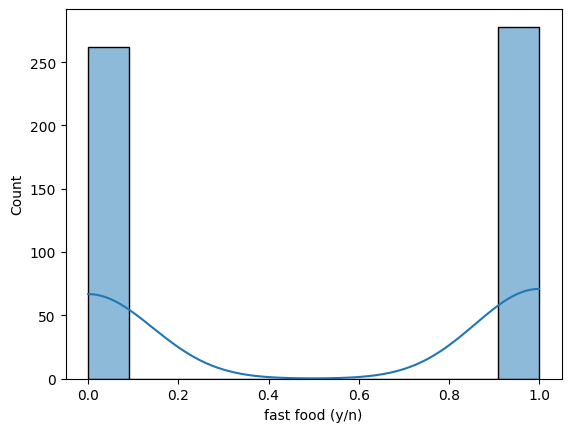

In [14]:
# two columns have missing data
cols=['marraige status (yrs)','fast food (y/n)']

for i in cols:
  sns.histplot(df[i],kde=True)
  plt.show()

In [15]:
df['fast food (y/n)'] = df['fast food (y/n)'].fillna(df['fast food (y/n)'].median())
df['marraige status (yrs)'] = df['marraige status (yrs)'].fillna(df['marraige status (yrs)'].median())

In [16]:
df.isnull().sum().sum()

np.int64(0)

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.shape

(541, 42)

In [19]:
df['pcos (y/n)'].value_counts()

,count
pcos (y/n),
0,364
1,177


In [20]:
df['ii    beta-hcg(miu/ml)'] = pd.to_numeric(df['ii    beta-hcg(miu/ml)'], errors='coerce')
df['amh(ng/ml)'] = pd.to_numeric(df['amh(ng/ml)'], errors='coerce')

df['ii    beta-hcg(miu/ml)'] = df['ii    beta-hcg(miu/ml)'].fillna(df['ii    beta-hcg(miu/ml)'].median())
df['amh(ng/ml)'] = df['amh(ng/ml)'].fillna(df['amh(ng/ml)'].median())

In [21]:
print(df.columns.tolist())

['pcos (y/n)', 'age (yrs)', 'weight (kg)', 'height(cm)', 'bmi', 'blood group', 'pulse rate(bpm)', 'rr (breaths/min)', 'hb(g/dl)', 'cycle(r/i)', 'cycle length(days)', 'marraige status (yrs)', 'pregnant(y/n)', 'no. of aborptions', 'i   beta-hcg(miu/ml)', 'ii    beta-hcg(miu/ml)', 'fsh(miu/ml)', 'lh(miu/ml)', 'fsh/lh', 'hip(inch)', 'waist(inch)', 'waist:hip ratio', 'tsh (miu/l)', 'amh(ng/ml)', 'prl(ng/ml)', 'vit d3 (ng/ml)', 'prg(ng/ml)', 'rbs(mg/dl)', 'weight gain(y/n)', 'hair growth(y/n)', 'skin darkening (y/n)', 'hair loss(y/n)', 'pimples(y/n)', 'fast food (y/n)', 'reg.exercise(y/n)', 'bp _systolic (mmhg)', 'bp _diastolic (mmhg)', 'follicle no. (l)', 'follicle no. (r)', 'avg. f size (l) (mm)', 'avg. f size (r) (mm)', 'endometrium (mm)']


In [22]:
X=df.drop('pcos (y/n)',axis=1)
y=df['pcos (y/n)']

In [23]:
#split the dataset
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 42 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   pcos (y/n)              541 non-null    int64  
 1   age (yrs)               541 non-null    int64  
 2   weight (kg)             541 non-null    float64
 3   height(cm)              541 non-null    float64
 4   bmi                     541 non-null    float64
 5   blood group             541 non-null    int64  
 6   pulse rate(bpm)         541 non-null    int64  
 7   rr (breaths/min)        541 non-null    int64  
 8   hb(g/dl)                541 non-null    float64
 9   cycle(r/i)              541 non-null    int64  
 10  cycle length(days)      541 non-null    int64  
 11  marraige status (yrs)   541 non-null    float64
 12  pregnant(y/n)           541 non-null    int64  
 13  no. of aborptions       541 non-null    int64  
 14  i   beta-hcg(miu/ml)    541 non-null    fl

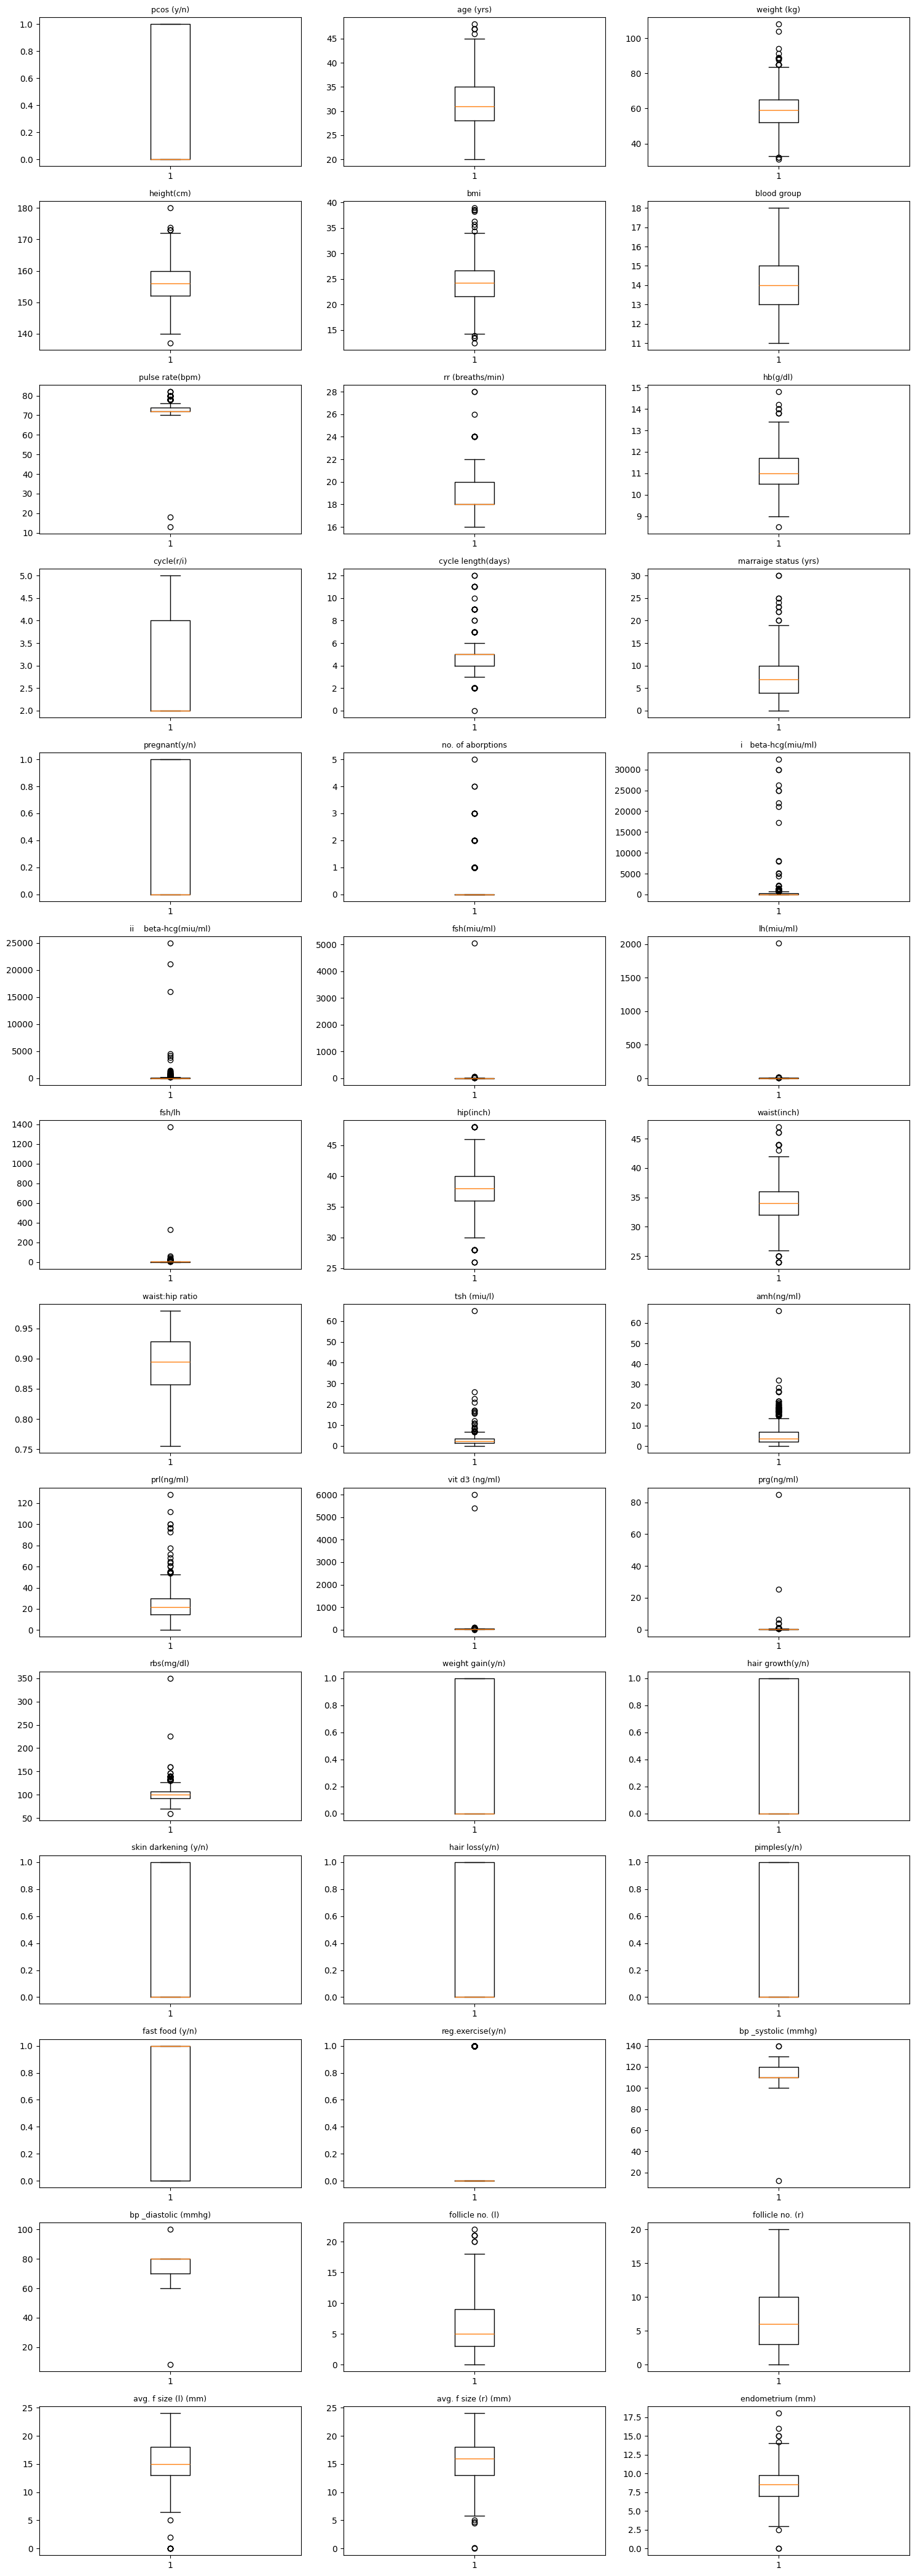

In [25]:
import matplotlib.pyplot as plt
import math

cols = df.select_dtypes(include=[np.number]).columns.tolist()

n_cols = 3
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col, fontsize=9)

# hide any unused subplots
for j in range(len(cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [26]:
skewed_cols = [
    'i   beta-hcg(miu/ml)',
    'ii    beta-hcg(miu/ml)',
    'amh(ng/ml)',
    'prl(ng/ml)',
    'tsh (miu/l)',
    'rbs(mg/dl)'
]

In [27]:
normal_cols=[]
for i in X.columns:
  if i in skewed_cols:
    continue
  normal_cols.append(i)

In [28]:
normal_cols

['age (yrs)',
 'weight (kg)',
 'height(cm)',
 'bmi',
 'blood group',
 'pulse rate(bpm)',
 'rr (breaths/min)',
 'hb(g/dl)',
 'cycle(r/i)',
 'cycle length(days)',
 'marraige status (yrs)',
 'pregnant(y/n)',
 'no. of aborptions',
 'fsh(miu/ml)',
 'lh(miu/ml)',
 'fsh/lh',
 'hip(inch)',
 'waist(inch)',
 'waist:hip ratio',
 'vit d3 (ng/ml)',
 'prg(ng/ml)',
 'weight gain(y/n)',
 'hair growth(y/n)',
 'skin darkening (y/n)',
 'hair loss(y/n)',
 'pimples(y/n)',
 'fast food (y/n)',
 'reg.exercise(y/n)',
 'bp _systolic (mmhg)',
 'bp _diastolic (mmhg)',
 'follicle no. (l)',
 'follicle no. (r)',
 'avg. f size (l) (mm)',
 'avg. f size (r) (mm)',
 'endometrium (mm)']

In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,FunctionTransformer
from sklearn.pipeline import Pipeline

#skew_pipelien
skew_pipeline = Pipeline([
    ("log_transform", FunctionTransformer(np.log1p, validate=True)),
    ("scaler", StandardScaler())
])

#normal_pipeline
normal_pipeline=Pipeline([
    ("scaler",StandardScaler())
])

preprocessor=ColumnTransformer([
    ("skewed",skew_pipeline,skewed_cols),
    ("normal",normal_pipeline,normal_cols)
])

In [30]:
preprocessor

ColumnTransformer(transformers=[('skewed',
                                 Pipeline(steps=[('log_transform',
                                                  FunctionTransformer(func=<ufunc 'log1p'>,
                                                                      validate=True)),
                                                 ('scaler', StandardScaler())]),
                                 ['i   beta-hcg(miu/ml)',
                                  'ii    beta-hcg(miu/ml)', 'amh(ng/ml)',
                                  'prl(ng/ml)', 'tsh (miu/l)', 'rbs(mg/dl)']),
                                ('normal',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['age (yrs)', 'weight (kg)', 'height(cm)'...
                                  'cycle length(days)', 'marraige status (yrs)',
                                  'pregnant(y/n)', 'no. of aborptions',
                                  'fsh(miu/ml)', 'lh(miu/ml)', 'fsh/lh',
                                  'hip(inch)', 'waist(inch)', 'waist:hip ratio',
                                  'vit d3 (ng/ml)', 'prg(ng/ml)',
                                  'weight gain(y/n)', 'hair growth(y/n)',
                                  'skin darkening (y/n)', 'hair loss(y/n)',
                                  'pimples(y/n)', 'fast food (y/n)',
                                  'reg.exercise(y/n)', 'bp _systolic (mmhg)',
                                  'bp _diastolic (mmhg)', ...])])

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(random_state=42, class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(random_state=42, class_weight='balanced'),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42, class_weight='balanced'),
    "XGBoost": XGBClassifier( random_state=42)
}

In [32]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

In [33]:
for col in X_train.columns:
    if X_train[col].dtype == 'object':
        print(col, X_train[col].unique()[:20])

In [34]:
X.isnull().sum()

,0
age (yrs),0
weight (kg),0
height(cm),0
bmi,0
blood group,0
pulse rate(bpm),0
rr (breaths/min),0
hb(g/dl),0
cycle(r/i),0
cycle length(days),0


In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models_for_sample_weight=["Gradient Boosting", "AdaBoost","XGBoost"]

fitted_pipelines = {}
results = []

for name, model in models.items():
    print(name)

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    if name in models_for_sample_weight:
        pipe.fit(X_train, y_train, model__sample_weight=sample_weights)
    else:
        pipe.fit(X_train, y_train)

    fitted_pipelines[name] = pipe

    y_pred = pipe.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results).sort_values(by="F1 Score", ascending=False).reset_index(drop=True)
results_df

Logistic Regression
Decision Tree
Random Forest
Gradient Boosting
AdaBoost
SVM
XGBoost


,Model,Accuracy,Precision,Recall,F1 Score
0,XGBoost,0.944954,0.941176,0.888889,0.914286
1,AdaBoost,0.926606,0.888889,0.888889,0.888889
2,Gradient Boosting,0.926606,0.911765,0.861111,0.885714
3,Random Forest,0.908257,0.964286,0.750000,0.843750
4,Logistic Regression,0.889908,0.800000,0.888889,0.842105
5,SVM,0.889908,0.815789,0.861111,0.837838
6,Decision Tree,0.853211,0.812500,0.722222,0.764706


In [36]:
params = {
    "XGBoost": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [3, 5, 7],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__subsample": [0.8, 1.0],
        "model__colsample_bytree": [0.8, 1.0]
    },
    "AdaBoost": {
        "model__n_estimators": [50, 100, 200],
        "model__learning_rate": [0.01, 0.1, 0.5, 1.0]
    },
    "Gradient Boosting": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [3, 5, 7],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__subsample": [0.8, 1.0]
    },
    "Random Forest": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [None, 5, 10, 15],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4]
    }
}

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

selected_models = ["XGBoost", "AdaBoost", "Gradient Boosting", "Random Forest"]

best_estimators = {}
tuned_results = []

for name in selected_models:
    print(f"Tuning {name}...")

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", models[name])
    ])

    grid = GridSearchCV(
        pipe,
        param_grid=params[name],
        scoring='f1',
        cv=5,
        n_jobs=-1,
        verbose=1
    )

    if name in models_for_sample_weight:  # Gradient Boosting, AdaBoost
        grid.fit(X_train, y_train, model__sample_weight=sample_weights)
    else:
        grid.fit(X_train, y_train)

    best_estimators[name] = grid.best_estimator_
    print(f"Best params for {name}: {grid.best_params_}")
    print(f"Best F1 (CV): {grid.best_score_:.4f}\n")

    # evaluate best estimator on test set
    y_pred = grid.best_estimator_.predict(X_test)

    tuned_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "Best CV F1": grid.best_score_
    })

tuned_results_df = pd.DataFrame(tuned_results).sort_values(by="F1 Score", ascending=False).reset_index(drop=True)
tuned_results_df

Tuning XGBoost...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best params for XGBoost: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200, 'model__subsample': 0.8}
Best F1 (CV): 0.8141

Tuning AdaBoost...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params for AdaBoost: {'model__learning_rate': 0.1, 'model__n_estimators': 100}
Best F1 (CV): 0.8244

Tuning Gradient Boosting...
Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best params for Gradient Boosting: {'model__learning_rate': 0.05, 'model__max_depth': 7, 'model__n_estimators': 300, 'model__subsample': 0.8}
Best F1 (CV): 0.8203

Tuning Random Forest...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best params for Random Forest: {'model__max_depth': None, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10, 'model__n_estimators': 300}
Best F1 (CV): 0.8270



,Model,Accuracy,Precision,Recall,F1 Score,Best CV F1
0,Random Forest,0.917431,0.909091,0.833333,0.869565,0.826951
1,Gradient Boosting,0.917431,0.909091,0.833333,0.869565,0.820251
2,AdaBoost,0.899083,0.837838,0.861111,0.849315,0.824360
3,XGBoost,0.899083,0.857143,0.833333,0.845070,0.814101


In [37]:
models

{'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42),
 'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
 'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42),
 'Gradient Boosting': GradientBoostingClassifier(random_state=42),
 'AdaBoost': AdaBoostClassifier(random_state=42),
 'SVM': SVC(class_weight='balanced', probability=True, random_state=42),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=True, eval_metric=None, feature_types=None,
               feature_weights=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=None, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=Non

In [38]:
final_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", models["XGBoost"])
])

final_pipe.fit(X_train, y_train)

y_pred=final_pipe.predict(X_test)

print(accuracy_score(y_test, y_pred))
print(recall_score(y_test, y_pred))
print(precision_score(y_test, y_pred))

0.9357798165137615
0.8333333333333334
0.967741935483871


In [39]:
import joblib
joblib.dump(final_pipe, "pcos_xgboost_model.pkl")

['pcos_xgboost_model.pkl']

In [40]:
X_train.shape[1]

41

In [52]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Dropout,Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

import tensorflow as tf

# process data first
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

model = Sequential([
    Input(shape=(X_train_processed.shape[1],)),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_processed, y_train,
    validation_data=(X_test_processed, y_test),
    epochs=25,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/25
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 216ms/step - accuracy: 0.5532 - loss: 0.8387 - precision: 0.4051 - recall: 0.7872 - val_accuracy: 0.7615 - val_loss: 0.6953 - val_precision: 0.6786 - val_recall: 0.5278
Epoch 2/25
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7708 - loss: 0.6434 - precision: 0.6981 - recall: 0.5248 - val_accuracy: 0.8073 - val_loss: 0.5847 - val_precision: 0.8947 - val_recall: 0.4722
Epoch 3/25
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8472 - loss: 0.5426 - precision: 0.9121 - recall: 0.5887 - val_accuracy: 0.8440 - val_loss: 0.5100 - val_precision: 0.8800 - val_recall: 0.6111
Epoch 4/25
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8449 - loss: 0.4851 - precision: 0.8304 - recall: 0.6596 - val_accuracy: 0.8807 - val_loss: 0.4541 - val_precision: 0.8966 - val_recall: 0.7222
Epoch 5/25
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8657 - loss: 0.4379 - precision: 0.8320 - recall: 0.7376 - val_accuracy: 0.8991 - val_loss: 0.4168 - v

In [53]:
results = model.evaluate(X_test_processed, y_test, verbose=1)
print(f"Test Loss: {results[0]:.4f}")
print(f"Test Accuracy: {results[1]:.4f}")
print(f"Test Precision: {results[2]:.4f}")
print(f"Test Recall: {results[3]:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9174 - loss: 0.3646 - precision: 0.9091 - recall: 0.8333
Test Loss: 0.3646
Test Accuracy: 0.9174
Test Precision: 0.9091
Test Recall: 0.8333


In [54]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_proba = model.predict(X_test_processed)
y_pred = (y_pred_proba > 0.5).astype(int)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step
[[70  3]
 [ 6 30]]
              precision    recall  f1-score   support

           0       0.92      0.96      0.94        73
           1       0.91      0.83      0.87        36

    accuracy                           0.92       109
   macro avg       0.92      0.90      0.90       109
weighted avg       0.92      0.92      0.92       109



In [55]:
model.save('pcos_predictor_ann.h5')

In [58]:
# values in the SAME ORDER as X_train.columns
patient_values = [
    28,      # age
    65.0,    # weight
    160.0,   # height
    25.4,    # bmi
    15,      # blood group
    74,      # pulse rate
    20,      # rr
    11.5,    # hb
    4,       # cycle(r/i)
    6,       # cycle length
    3.0,     # marraige status
    0,       # pregnant
    0,       # no. of abortions
    1.99,    # i beta-hcg
    1.99,    # ii beta-hcg
    6.5,     # fsh
    8.2,     # lh
    0.79,    # fsh/lh
    38,      # hip
    34,      # waist
    0.89,    # waist:hip
    3.2,     # tsh
    6.8,     # amh
    22.0,    # prl
    28.0,    # vit d3
    0.5,     # prg
    95.0,    # rbs
    1,       # weight gain
    1,       # hair growth
    1,       # skin darkening
    0,       # hair loss
    1,       # pimples
    1.0,     # fast food
    0,       # reg.exercise
    120,     # bp systolic
    80,      # bp diastolic
    14,      # follicle L
    16,      # follicle R
    6.0,     # avg f size L
    6.5,     # avg f size R
    8.0      # endometrium
]

new_patient = pd.DataFrame([patient_values], columns=X_train.columns)

new_patient_processed = preprocessor.transform(new_patient)

prediction_proba = model.predict(new_patient_processed)
prediction = (prediction_proba > 0.5).astype(int)

print(f"PCOS Probability: {prediction_proba[0][0]:.4f}")
print(f"Predicted Class: {'PCOS Positive' if prediction[0][0] == 1 else 'PCOS Negative'}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step
PCOS Probability: 0.9873
Predicted Class: PCOS Positive


In [42]:
df.head(2)

,pcos (y/n),age (yrs),weight (kg),height(cm),bmi,blood group,pulse rate(bpm),rr (breaths/min),hb(g/dl),cycle(r/i),cycle length(days),marraige status (yrs),pregnant(y/n),no. of aborptions,i beta-hcg(miu/ml),ii beta-hcg(miu/ml),fsh(miu/ml),lh(miu/ml),fsh/lh,hip(inch),waist(inch),waist:hip ratio,tsh (miu/l),amh(ng/ml),prl(ng/ml),vit d3 (ng/ml),prg(ng/ml),rbs(mg/dl),weight gain(y/n),hair growth(y/n),skin darkening (y/n),hair loss(y/n),pimples(y/n),fast food (y/n),reg.exercise(y/n),bp _systolic (mmhg),bp _diastolic (mmhg),follicle no. (l),follicle no. (r),avg. f size (l) (mm),avg. f size (r) (mm),endometrium (mm)
0,0,28,44.6,152.0,19.300000,15,78,22,10.48,2,5,7.0,0,0,1.99,1.99,7.95,3.68,2.160326,36,30,0.833333,0.68,2.07,45.16,17.1,0.57,92.0,0,0,0,0,0,1.0,0,110,80,3,3,18.0,18.0,8.5
1,0,36,65.0,161.5,24.921163,15,74,20,11.70,2,5,11.0,1,0,60.80,1.99,6.73,1.09,6.174312,38,32,0.842105,3.16,1.53,20.09,61.3,0.97,92.0,0,0,0,0,0,0.0,0,120,70,3,5,15.0,14.0,3.7
